<a href="https://colab.research.google.com/github/dinder3685/Cmaera-resoultion-/blob/main/Focal_Length_Plot_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Plot saved to focal_length_vs_percentage.png


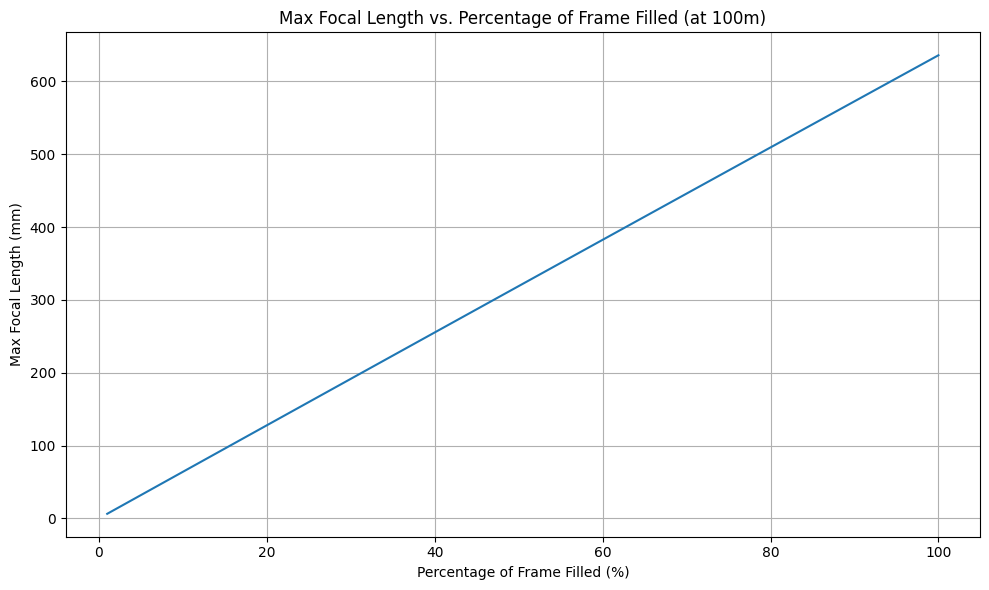

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_focal_length(object_height_mm, image_height_mm, distance_mm):
    """
    Calculates the focal length using the thin-lens magnification relation.

    Args:
        object_height_mm (float): The height of the object in millimeters.
        image_height_mm (float): The desired height of the image on the sensor in millimeters.
        distance_mm (float): The distance to the object in millimeters.

    Returns:
        float: The calculated focal length in millimeters.
    """
    # Magnification M = h_image / h_object
    magnification = image_height_mm / object_height_mm
    # Focal length f = (M * Z_object) / (1 + M)
    focal_length = (magnification * distance_mm) / (1 + magnification)
    return focal_length

def generate_focal_length_plot():
    """
    Generates and saves a plot showing the relationship between focal length
    and the percentage of the frame filled by an object.
    """
    # Camera and object parameters
    sensor_width_mm = 6.4
    image_width_px = 1920
    object_height_cm = 100
    object_height_mm = object_height_cm * 10
    distance_m = 100
    distance_mm = distance_m * 1000

    # Range of percentages to fill the frame
    percentages = np.arange(1, 101, 1)

    # Calculate the corresponding image height in mm for each percentage
    # The image sensor width is used here as the total frame width
    image_heights_mm = (percentages / 100) * sensor_width_mm

    # Calculate the focal length for each percentage
    focal_lengths_mm = [
        calculate_focal_length(object_height_mm, h, distance_mm)
        for h in image_heights_mm
    ]

    # Create a DataFrame for easy handling and plotting
    df = pd.DataFrame({
        'Percentage': percentages,
        'Focal Length (mm)': focal_lengths_mm
    })

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(df['Percentage'], df['Focal Length (mm)'])
    plt.title('Max Focal Length vs. Percentage of Frame Filled (at 100m)')
    plt.xlabel('Percentage of Frame Filled (%)')
    plt.ylabel('Max Focal Length (mm)')
    plt.grid(True)
    plt.tight_layout()

    # Save the plot to a file
    plt.savefig('focal_length_vs_percentage.png')
    print("Plot saved to focal_length_vs_percentage.png")

if __name__ == '__main__':
    generate_focal_length_plot()

Styled plot saved to focal_length_vs_percentage_styled.png


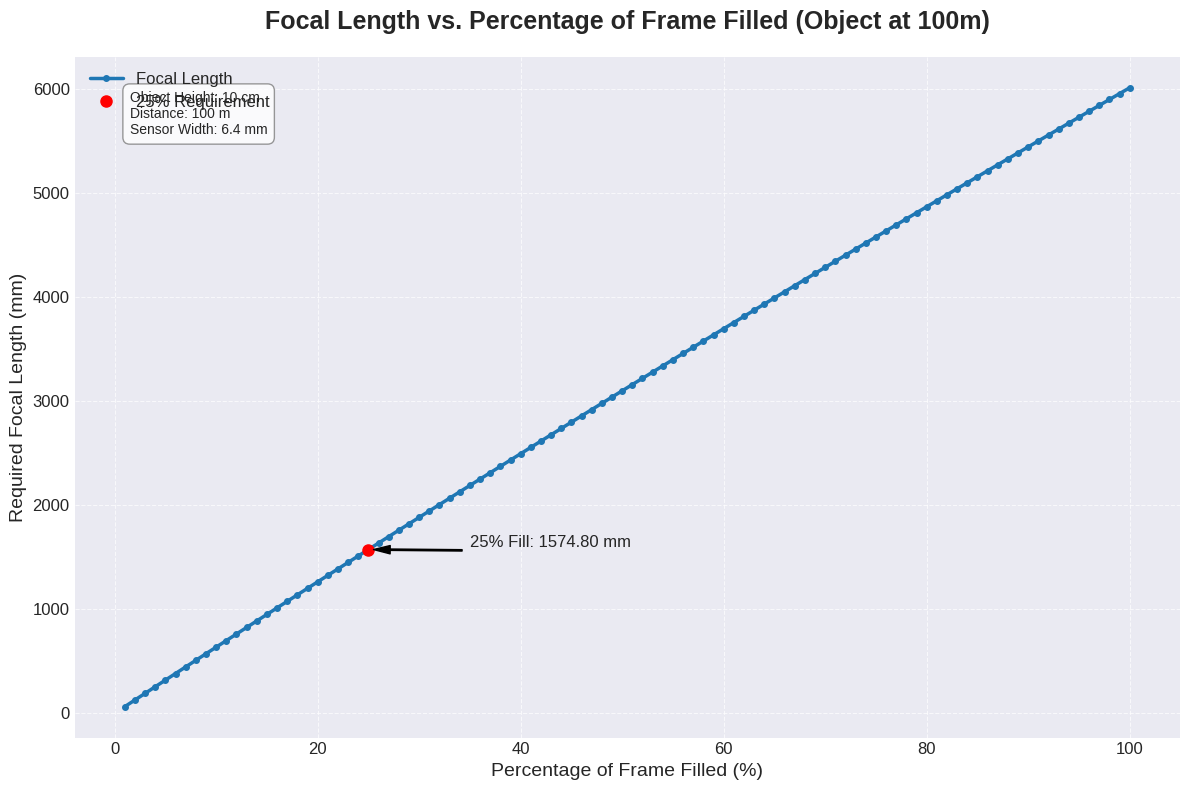

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_focal_length(object_height_mm, image_height_mm, distance_mm):
    """
    Calculates the focal length using the thin-lens magnification relation.

    Args:
        object_height_mm (float): The height of the object in millimeters.
        image_height_mm (float): The desired height of the image on the sensor in millimeters.
        distance_mm (float): The distance to the object in millimeters.

    Returns:
        float: The calculated focal length in millimeters.
    """
    # Magnification M = h_image / h_object
    magnification = image_height_mm / object_height_mm
    # Focal length f = (M * Z_object) / (1 + M)
    focal_length = (magnification * distance_mm) / (1 + magnification)
    return focal_length

def generate_focal_length_plot():
    """
    Generates and saves a more detailed plot showing the relationship between focal length
    and the percentage of the frame filled by a 10 cm object.
    """
    # Use a professional plot style
    plt.style.use('seaborn-v0_8-darkgrid')

    # Camera and object parameters
    sensor_width_mm = 6.4
    image_width_px = 1920
    object_height_cm = 10
    object_height_mm = object_height_cm * 10
    distance_m = 100
    distance_mm = distance_m * 1000

    # Range of percentages to fill the frame
    percentages = np.arange(1, 101, 1)

    # Calculate the corresponding image height in mm for each percentage
    image_heights_mm = (percentages / 100) * sensor_width_mm

    # Calculate the focal length for each percentage
    focal_lengths_mm = [
        calculate_focal_length(object_height_mm, h, distance_mm)
        for h in image_heights_mm
    ]

    # Create a DataFrame for easy handling and plotting
    df = pd.DataFrame({
        'Percentage': percentages,
        'Focal Length (mm)': focal_lengths_mm
    })

    # Create the plot with a larger figure size
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(
        df['Percentage'],
        df['Focal Length (mm)'],
        color='#1f77b4',
        linewidth=2.5,
        marker='o',
        markersize=4,
        label='Focal Length'
    )

    # Add a title and axis labels with improved formatting
    ax.set_title(
        'Focal Length vs. Percentage of Frame Filled (Object at 100m)',
        fontsize=18,
        pad=20,
        fontweight='bold'
    )
    ax.set_xlabel('Percentage of Frame Filled (%)', fontsize=14)
    ax.set_ylabel('Required Focal Length (mm)', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Add a text box to display constant parameters
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(
        0.05, 0.95,
        f'Object Height: {object_height_cm} cm\nDistance: {distance_m} m\nSensor Width: {sensor_width_mm} mm',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=props
    )

    # Add annotation for the 25% design requirement
    # Find the row where Percentage is 25%
    req_percentage = 25
    req_focal_length = df[df['Percentage'] == req_percentage]['Focal Length (mm)'].values[0]

    ax.plot(req_percentage, req_focal_length, 'ro', markersize=8, label='25% Requirement')
    ax.annotate(
        f'25% Fill: {req_focal_length:.2f} mm',
        xy=(req_percentage, req_focal_length),
        xytext=(req_percentage + 10, req_focal_length + 20),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
        fontsize=12
    )

    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left', fontsize=12)
    plt.tight_layout()

    # Save the plot to a file
    plt.savefig('focal_length_vs_percentage_styled.png')
    print("Styled plot saved to focal_length_vs_percentage_styled.png")

if __name__ == '__main__':
    generate_focal_length_plot()


Heatmap saved to focal_length_heatmap.png


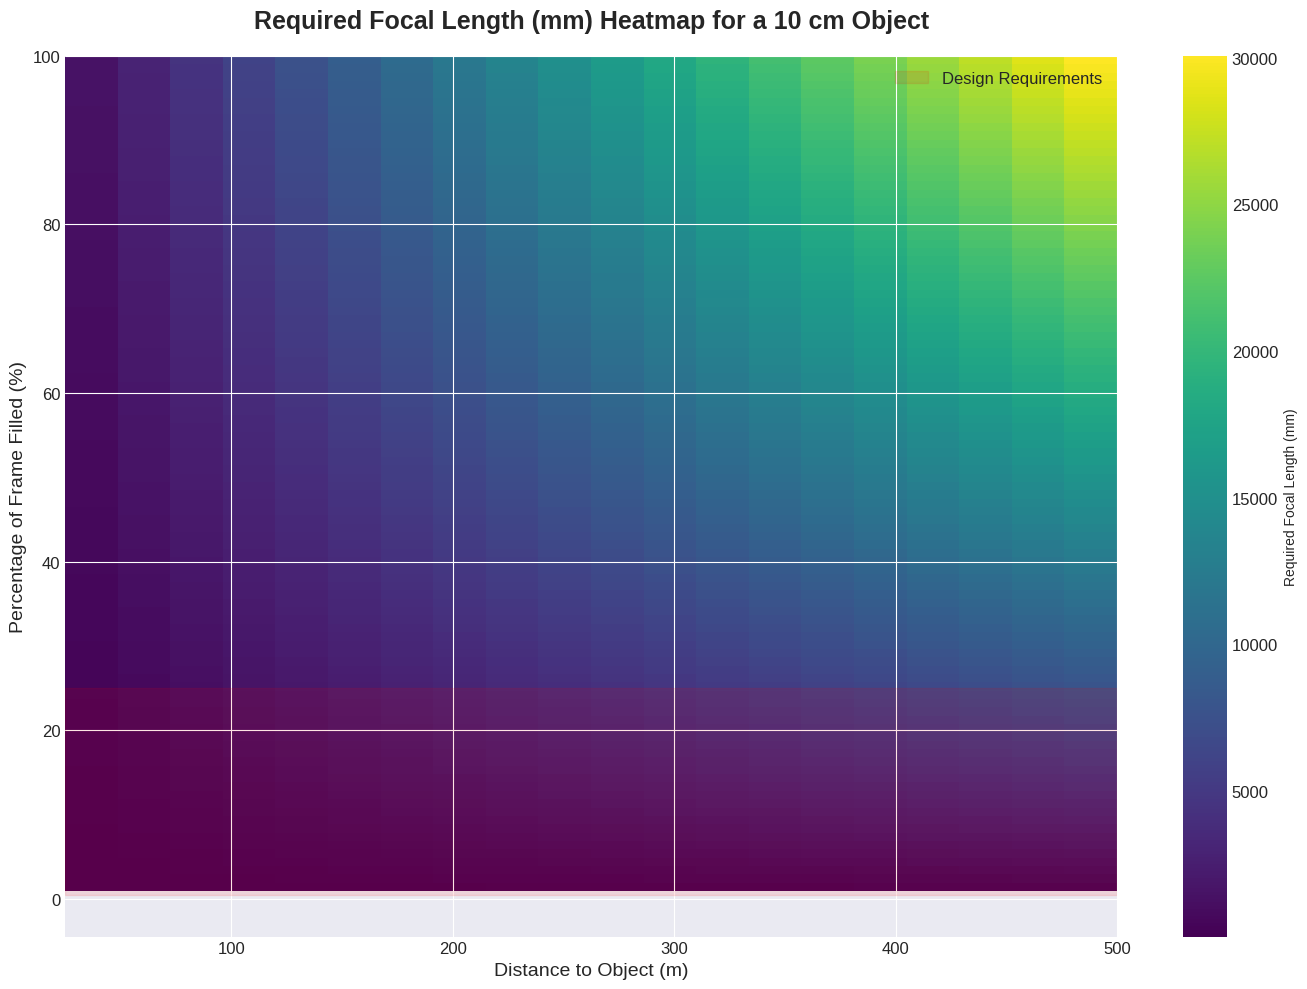

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_focal_length(object_height_mm, image_height_mm, distance_mm):
    """
    Calculates the focal length using the thin-lens magnification relation.

    Args:
        object_height_mm (float): The height of the object in millimeters.
        image_height_mm (float): The desired height of the image on the sensor in millimeters.
        distance_mm (float): The distance to the object in millimeters.

    Returns:
        float: The calculated focal length in millimeters.
    """
    # Magnification M = h_image / h_object
    magnification = image_height_mm / object_height_mm
    # Focal length f = (M * Z_object) / (1 + M)
    focal_length = (magnification * distance_mm) / (1 + magnification)
    return focal_length

def generate_focal_length_plot():
    """
    Generates and saves a heatmap showing the required focal length
    as a function of object distance and percentage of frame filled.
    """
    # Use a professional plot style
    plt.style.use('seaborn-v0_8-darkgrid')

    # Camera and object parameters
    sensor_width_mm = 6.4
    object_height_cm = 10
    object_height_mm = object_height_cm * 10

    # Define the ranges for the heatmap axes
    distances_m = np.arange(25, 525, 25)
    percentages = np.arange(1, 101, 1)

    # Create a grid to store the calculated focal lengths
    focal_lengths_grid = np.zeros((len(percentages), len(distances_m)))

    # Populate the grid with focal length values
    for i, p in enumerate(percentages):
        # Calculate the corresponding image height in mm for each percentage
        image_height_mm = (p / 100) * sensor_width_mm
        for j, d in enumerate(distances_m):
            distance_mm = d * 1000
            focal_lengths_grid[i, j] = calculate_focal_length(object_height_mm, image_height_mm, distance_mm)

    # Create the heatmap plot with a larger figure size
    fig, ax = plt.subplots(figsize=(14, 10))
    im = ax.imshow(
        focal_lengths_grid,
        cmap='viridis',
        aspect='auto',
        origin='lower',
        extent=[distances_m.min(), distances_m.max(), percentages.min(), percentages.max()]
    )

    # Add a color bar
    cbar = fig.colorbar(im, ax=ax, label='Required Focal Length (mm)')
    cbar.ax.tick_params(labelsize=12)

    # Add a title and axis labels with improved formatting
    ax.set_title(
        'Required Focal Length (mm) Heatmap for a 10 cm Object',
        fontsize=18,
        pad=20,
        fontweight='bold'
    )
    ax.set_xlabel('Distance to Object (m)', fontsize=14)
    ax.set_ylabel('Percentage of Frame Filled (%)', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Add annotations for the design requirements for clarity
    req_percentage_min = 10 / 1920 * 100
    req_percentage_max = 25
    ax.axhspan(req_percentage_min, req_percentage_max, color='red', alpha=0.1, label='Design Requirements')

    ax.legend(loc='upper right', fontsize=12)

    plt.tight_layout()

    # Save the plot to a file
    plt.savefig('focal_length_heatmap.png')
    print("Heatmap saved to focal_length_heatmap.png")

if __name__ == '__main__':
    generate_focal_length_plot()



Heatmap saved to focal_length_heatmap.png


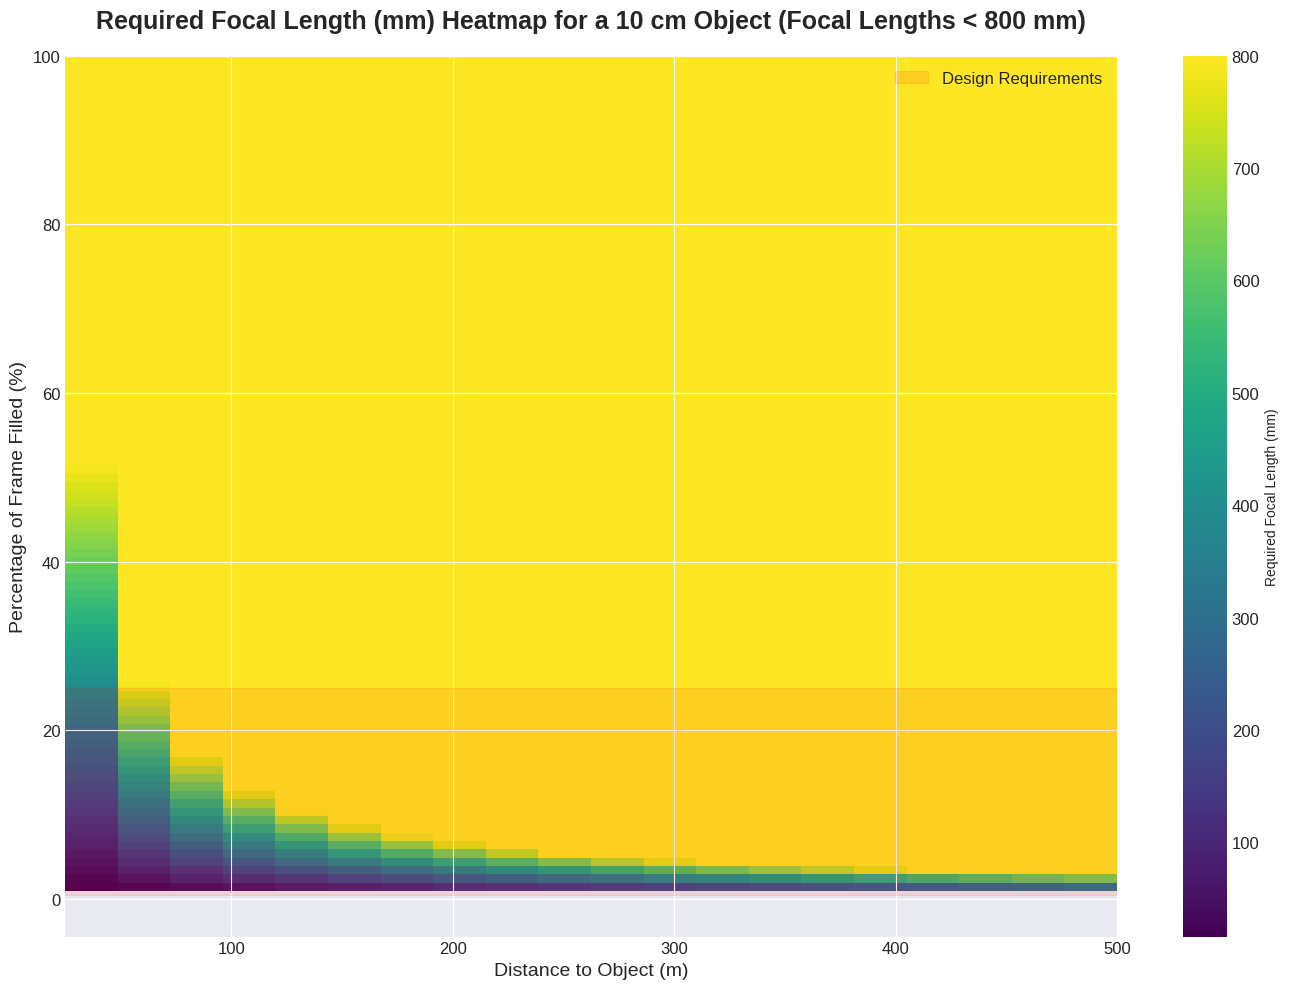

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_focal_length(object_height_mm, image_height_mm, distance_mm):
    """
    Calculates the focal length using the thin-lens magnification relation.

    Args:
        object_height_mm (float): The height of the object in millimeters.
        image_height_mm (float): The desired height of the image on the sensor in millimeters.
        distance_mm (float): The distance to the object in millimeters.

    Returns:
        float: The calculated focal length in millimeters.
    """
    # Magnification M = h_image / h_object
    magnification = image_height_mm / object_height_mm
    # Focal length f = (M * Z_object) / (1 + M)
    focal_length = (magnification * distance_mm) / (1 + magnification)
    return focal_length

def generate_focal_length_plot():
    """
    Generates and saves a heatmap showing the required focal length
    as a function of object distance and percentage of frame filled,
    with a focus on focal lengths up to 800 mm.
    """
    # Use a professional plot style
    plt.style.use('seaborn-v0_8-darkgrid')

    # Camera and object parameters
    sensor_width_mm = 6.4
    object_height_cm = 10
    object_height_mm = object_height_cm * 10

    # Define the ranges for the heatmap axes
    distances_m = np.arange(25, 525, 25)
    percentages = np.arange(1, 101, 1)

    # Create a grid to store the calculated focal lengths
    focal_lengths_grid = np.zeros((len(percentages), len(distances_m)))

    # Populate the grid with focal length values
    for i, p in enumerate(percentages):
        # Calculate the corresponding image height in mm for each percentage
        image_height_mm = (p / 100) * sensor_width_mm
        for j, d in enumerate(distances_m):
            distance_mm = d * 1000
            focal_lengths_grid[i, j] = calculate_focal_length(object_height_mm, image_height_mm, distance_mm)

    # Create the heatmap plot with a larger figure size
    fig, ax = plt.subplots(figsize=(14, 10))
    im = ax.imshow(
        focal_lengths_grid,
        cmap='viridis',
        aspect='auto',
        origin='lower',
        extent=[distances_m.min(), distances_m.max(), percentages.min(), percentages.max()],
        vmax=800  # Set the maximum value for the color scale to 800 mm
    )

    # Add a color bar
    cbar = fig.colorbar(im, ax=ax, label='Required Focal Length (mm)')
    cbar.ax.tick_params(labelsize=12)

    # Add a title and axis labels with improved formatting
    ax.set_title(
        'Required Focal Length (mm) Heatmap for a 10 cm Object (Focal Lengths < 800 mm)',
        fontsize=18,
        pad=20,
        fontweight='bold'
    )
    ax.set_xlabel('Distance to Object (m)', fontsize=14)
    ax.set_ylabel('Percentage of Frame Filled (%)', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Add annotations for the design requirements for clarity
    req_percentage_min = 10 / 1920 * 100
    req_percentage_max = 25
    ax.axhspan(req_percentage_min, req_percentage_max, color='red', alpha=0.1, label='Design Requirements')

    ax.legend(loc='upper right', fontsize=12)

    plt.tight_layout()

    # Save the plot to a file
    plt.savefig('focal_length_heatmap.png')
    print("Heatmap saved to focal_length_heatmap.png")

if __name__ == '__main__':
    generate_focal_length_plot()

